# K-Means Clustering

<details>
<summary><strong>What is K-Means?</strong></summary>

K-Means is an **unsupervised machine learning algorithm** used to group similar data points into **K clusters**.

Unlike classification, K-Means **does not require labels**. It discovers hidden patterns in the data by grouping similar samples together.

**Goal:** Minimize the distance between data points and the center of their assigned cluster (centroid).

</details>

---

<details>
<summary><strong>What is a Cluster?</strong></summary>

A **cluster** is a group of data points that are **similar to each other**.

For example, in customer segmentation:

- **Cluster 1:** Young customers with low spending.
- **Cluster 2:** Middle-aged customers with medium spending.
- **Cluster 3:** High-income customers with high spending.

Data points inside the same cluster are more similar than points in other clusters.

</details>

---

<details>
<summary><strong>What is K?</strong></summary>

`K` is the **number of clusters** you want the algorithm to create.

Example:

```python
KMeans(n_clusters=3)
```

The algorithm will divide the data into **3 clusters**.

Choosing the correct value of **K** is important because it affects the quality of the clustering.

</details>

---

<details>
<summary><strong>How Does K-Means Work?</strong></summary>

### Step 1
Choose the number of clusters (**K**).

### Step 2
Randomly initialize **K centroids**.

### Step 3
Calculate the distance from every data point to each centroid.

### Step 4
Assign each point to the nearest centroid.

### Step 5
Recalculate each centroid as the mean of all points assigned to it without calculate centroid point in mean equation.

### Step 6
Repeat Steps 3–5 until the centroids stop changing or the maximum number of iterations is reached.

</details>

---

<details>
<summary><strong>What is a Centroid?</strong></summary>

A **centroid** is the center of a cluster.

It is calculated as the **mean (average)** of all data points in that cluster.

As the algorithm runs, centroids move until they reach the best positions that represent their clusters.

</details>

---

<details>
<summary><strong>Distance Formula</strong></summary>

K-Means uses **Euclidean Distance** by default.

$$
d=\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}
$$

The nearest centroid determines which cluster a data point belongs to.

</details>

---

<details>
<summary><strong>Training Process</strong></summary>

```python
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)
```

During training, K-Means:

- Initializes centroids.
- Assigns points to the nearest centroid.
- Updates centroid locations.
- Repeats until convergence.

</details>

---

<details>
<summary><strong>Predicting a Cluster</strong></summary>

```python
cluster = model.predict(new_data)
```

The model calculates the distance from the new sample to every centroid.

The sample is assigned to the **nearest cluster**.

</details>

---

<details>
<summary><strong>Choosing the Best K (Elbow Method)</strong></summary>

The **Elbow Method** helps determine the optimal number of clusters.

Steps:

1. Train K-Means for different values of K.
2. Compute the **WCSS (Within-Cluster Sum of Squares)**.
3. Plot **K vs WCSS**.
4. Choose the **elbow point**, where the decrease in WCSS starts to slow.

</details>

---

<details>
<summary><strong>Feature Scaling</strong></summary>

K-Means is a **distance-based algorithm**.

Features should be scaled before training.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

Without scaling, features with larger values dominate the distance calculation.

</details>

---

<details>
<summary><strong>Advantages</strong></summary>

- Simple and easy to understand.
- Fast on small and medium datasets.
- Easy to implement.
- Works well when clusters are compact and well separated.
- Useful for customer segmentation, image compression, and anomaly detection.

</details>

---

<details>
<summary><strong>Disadvantages</strong></summary>

- You must choose **K** in advance.
- Sensitive to the initial centroid positions.
- Sensitive to outliers.
- Assumes clusters are roughly spherical.
- Performance decreases when clusters overlap.

</details>

---

<details>
<summary><strong>Applications</strong></summary>

Common uses of K-Means include:

- Customer Segmentation
- Market Analysis
- Image Compression
- Document Clustering
- Recommendation Systems
- Anomaly Detection

</details>

---

<details>
<summary><strong>Summary</strong></summary>

- K-Means is an **unsupervised learning** algorithm.
- Used for **clustering** similar data points.
- A **cluster** is a group of similar samples.
- A **centroid** is the center of a cluster.
- The algorithm repeatedly:
  1. Assigns points to the nearest centroid.
  2. Updates the centroid.
- Uses **Euclidean Distance** by default.
- Requires **feature scaling**.
- The **Elbow Method** helps choose the best value of **K**.

</details>

In [34]:
from sklearn.cluster import KMeans
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from matplotlib  import pyplot  as plt


In [35]:
df=pd.read_csv('CSVdata/income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income')

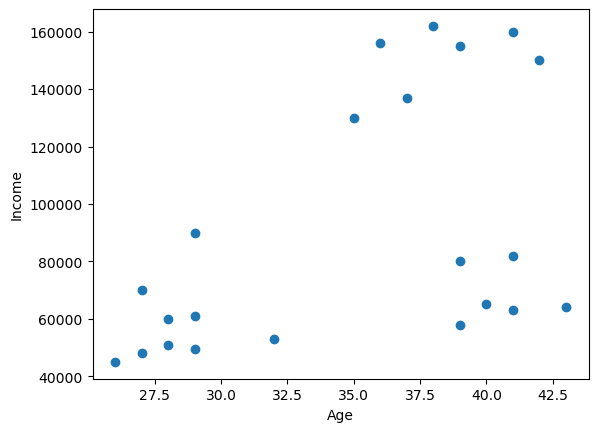

In [36]:
plt.scatter(df['Age'],df['Income($)'])
plt.xlabel("Age")
plt.ylabel("Income")

## K-Means Evaluation Methods

### Inertia
Measures how close each data point is to the centroid of its assigned cluster.

- Lower Inertia → More compact clusters.
- Commonly used with the **Elbow Method** to choose the best number of clusters ($K$).

### Silhouette Score
Measures how well each data point fits within its cluster compared to other clusters.

- Close to **1** → Well-separated clusters.
- Close to **0** → Overlapping clusters.
- close to **-1** → Poor clustering.

> **In short:** Inertia measures **cluster compactness**, while Silhouette Score measures **cluster separation and quality**.

### `km.inertia_`

- **Within-Cluster Sum of Squares (WCSS)**.
- Measures the total squared distance between each data point and its assigned centroid.

**Equation:**

$$
\text{Inertia}=\sum_{i=1}^{n}\|x_i-c_i\|^2
$$

Where:
- $x_i$ = data point
- $c_i$ = centroid of the assigned cluster
- $n$ = total number of data points

- Lower inertia indicates more compact and better-defined clusters.
- Commonly used in the **Elbow Method** to determine the optimal number of clusters (**K**).

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Age', 'Income($)']])

In [38]:
# I identify the number of clusters depend on the previous scattering of the data

km = KMeans(n_clusters=3, random_state=42)
y_pred = km.fit_predict(X_scaled)
print(y_pred)



[1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 2]


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [39]:
# To get the actual value of centroids not the scaled value
print("Scaled Values to Centroids : \n",km.cluster_centers_.reshape(-1,1))
centroids = scaler.inverse_transform(km.cluster_centers_)
print("Actual Values to Centroids : \n",centroids.reshape(-1,1))

Scaled Values to Centroids : 
 [[ 0.60143983]
 [ 1.40141653]
 [-1.1247901 ]
 [-0.74862223]
 [ 0.98550535]
 [-0.51205261]]
Actual Values to Centroids : 
 [[3.82857143e+01]
 [1.50000000e+05]
 [2.83333333e+01]
 [5.86111111e+04]
 [4.05000000e+01]
 [6.86666667e+04]]


In [40]:
df['cluster']=y_pred
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0


In [41]:
from sklearn.metrics import silhouette_score

# How well separated are your clusters? [-1,1]
# This function evaluates how good your K-Means clusters are
# Are the points in the same cluster close to each other, and are they far from points in other clusters?
silhouette = silhouette_score(
    df[['Age', 'Income($)']],
    y_pred
)

print("Silhouette Score:", round(silhouette, 3))
print("Inertia:", round(km.inertia_, 3))

Silhouette Score: 0.345
Inertia: 3.889


In [42]:
print("Centroids Matrix shape : ",centroids.shape)

Centroids Matrix shape :  (3, 2)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22404\1215014961.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


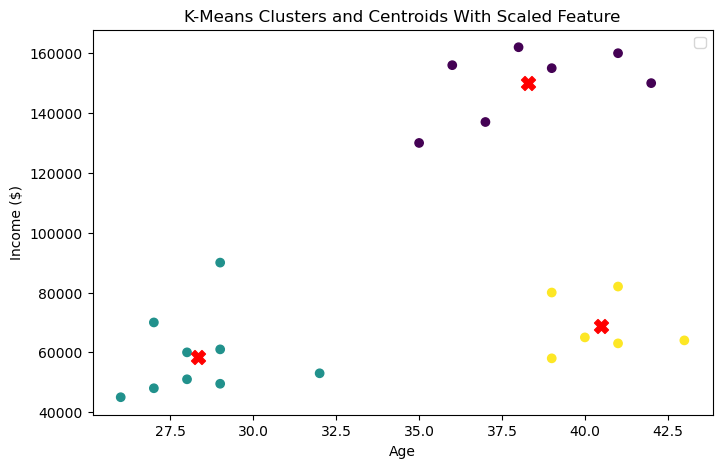

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.scatter(
    df['Age'],
    df['Income($)'],
    # Use the value in the cluster column to determine the color of each point
    c=df['cluster'],
    cmap='viridis'
)

#This gives you the coordinates of the 3 centroids  km.cluster_centers_[,]
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color="red",
    marker="X",
    s=100
)

plt.xlabel("Age")
plt.ylabel("Income ($)")
plt.title("K-Means Clusters and Centroids With Scaled Feature")
plt.legend()
plt.show()

### Task :Evaluate different values of **K** using Silhouette Score to determine the optimal number of clusters for the K-Means model.

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#it checks: 
# Are points close to their own cluster?
# Are different clusters well separated?

scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    # in silhouette_score large score is the best on it indicate how points fit t
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

best_k = scores.index(max(scores)) + 2
print(scores)
print("Best K:", best_k)
print("Best Silhouette Score:", max(scores))





[np.float64(0.5113962452402268), np.float64(0.7119890290065082), np.float64(0.6216098179564306), np.float64(0.4642014036012108), np.float64(0.4546240988692569), np.float64(0.44179913325874287), np.float64(0.3051395386801921), np.float64(0.28177422253285317), np.float64(0.2547224355177983)]
Best K: 3
Best Silhouette Score: 0.7119890290065082


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi